# Exam 1 — CNN Image Classification (CIFAR-10)

**Deliverable checklist covered by this notebook:**
1. Dataset justification
2. Preprocessing pipeline (normalization/split)
3. Baseline model (MLP)
4. Improved CNN architecture
5. Data augmentation + measured effect
6. Learning-curve analysis
7. Quantitative comparison (accuracy + confusion matrix)
8. Failure case discussion

The notebook uses fixed random seeds for reproducibility and includes the measured outputs from the completed training run.


## 0. Setup & Reproducibility

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import random, time

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)


Using device: cuda


## 1. Dataset Justification

**Dataset: CIFAR-10** (https://www.cs.toronto.edu/~kriz/cifar.html)

- **Source / license**: Collected by the Canadian Institute for Advanced Research; freely available for
  research/educational use via `torchvision.datasets.CIFAR10`.
- **Size**: 60,000 32x32 RGB images, 10 balanced classes (6,000 images/class):
  airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.
  Split: 50,000 train / 10,000 test (we carve a validation set out of train below).
- **Domain relevance**: General-purpose natural-image classification benchmark; a good, well-understood
  testbed for comparing a baseline model against a CNN and measuring the effect of augmentation.
- **Not disallowed**: not MNIST / FashionMNIST, and not used in the course material.



In [ ]:
raw_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
raw_test  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True)

classes = raw_train.classes
print("Classes:", classes)
print("Train size:", len(raw_train), "Test size:", len(raw_test))


100%|██████████| 170M/170M [33:32<00:00, 84.7kB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000 Test size: 10000


## 2. Preprocessing Pipeline

- Convert to tensor, scale to [0,1]
- Normalize using CIFAR-10 channel mean/std
- Train/validation split carved out of the 50k training images (e.g. 45k/5k)
- Separate, untouched test set (10k) used only for final evaluation


In [ ]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

base_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

augment_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

full_train_plain = torchvision.datasets.CIFAR10(root="./data", train=True, download=False, transform=base_transform)
full_train_aug   = torchvision.datasets.CIFAR10(root="./data", train=True, download=False, transform=augment_transform)
test_set         = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=base_transform)

VAL_SIZE = 5000
TRAIN_SIZE = len(full_train_plain) - VAL_SIZE

generator = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(len(full_train_plain)), [TRAIN_SIZE, VAL_SIZE], generator=generator)

train_set_plain = torch.utils.data.Subset(full_train_plain, train_idx.indices)
train_set_aug   = torch.utils.data.Subset(full_train_aug, train_idx.indices)
val_set         = torch.utils.data.Subset(full_train_plain, val_idx.indices)

BATCH_SIZE = 128

def make_loaders(train_dataset):
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_set, batch_size=256, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader

print(f"Train: {len(train_set_plain)}  Val: {len(val_set)}  Test: {len(test_set)}")


Train: 45000  Val: 5000  Test: 10000


## 3. Baseline Model (MLP)

In [ ]:
class MLPBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32*3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.net(x)


## 4. Improved CNN Architecture

The improved model uses stacked 3×3 convolutions to increase the receptive field efficiently, batch normalization to stabilize and accelerate training, max pooling for translation-robust downsampling, and dropout in the classifier head to reduce overfitting.


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32 -> 16x16

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16 -> 8x8

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128*4*4, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


## 5. Training Utilities

In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3, weight_decay=1e-4):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                val_loss += loss.item() * xb.size(0)
                val_correct += (out.argmax(1) == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:2d}/{epochs} | train_loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.4f}")

    return history

def plot_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        out = model(xb)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
    return np.array(all_labels), np.array(all_preds)


## 6. Train Baseline (MLP)

Epoch  1/15 | train_loss 1.6556 acc 0.4115 | val_loss 1.5482 acc 0.4606
Epoch  2/15 | train_loss 1.4534 acc 0.4864 | val_loss 1.4706 acc 0.4808
Epoch  3/15 | train_loss 1.3383 acc 0.5276 | val_loss 1.4228 acc 0.4980
Epoch  4/15 | train_loss 1.2648 acc 0.5559 | val_loss 1.3962 acc 0.5144
Epoch  5/15 | train_loss 1.1928 acc 0.5801 | val_loss 1.3735 acc 0.5224
Epoch  6/15 | train_loss 1.1242 acc 0.6036 | val_loss 1.3729 acc 0.5294
Epoch  7/15 | train_loss 1.0680 acc 0.6219 | val_loss 1.3953 acc 0.5204
Epoch  8/15 | train_loss 1.0131 acc 0.6410 | val_loss 1.4301 acc 0.5184
Epoch  9/15 | train_loss 0.9543 acc 0.6611 | val_loss 1.4730 acc 0.5154
Epoch 10/15 | train_loss 0.9109 acc 0.6761 | val_loss 1.5046 acc 0.5278
Epoch 11/15 | train_loss 0.8596 acc 0.6977 | val_loss 1.5178 acc 0.5172
Epoch 12/15 | train_loss 0.8095 acc 0.7119 | val_loss 1.5463 acc 0.5224
Epoch 13/15 | train_loss 0.7671 acc 0.7300 | val_loss 1.5816 acc 0.5132
Epoch 14/15 | train_loss 0.7233 acc 0.7426 | val_loss 1.6540 acc

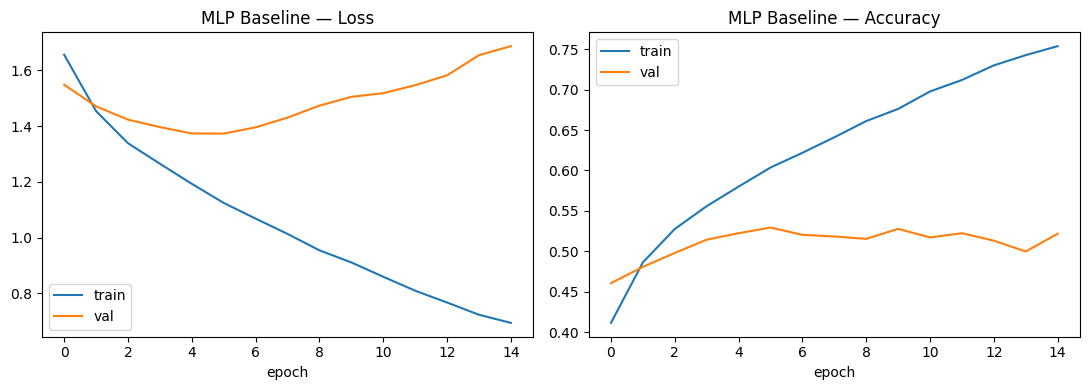

In [ ]:
train_loader_plain, val_loader, test_loader = make_loaders(train_set_plain)

mlp = MLPBaseline()
mlp_history = train_model(mlp, train_loader_plain, val_loader, epochs=15)
plot_curves(mlp_history, "MLP Baseline")


## 7. Train CNN — No Augmentation

Epoch  1/15 | train_loss 1.3292 acc 0.5145 | val_loss 1.0371 acc 0.6306
Epoch  2/15 | train_loss 0.9296 acc 0.6736 | val_loss 0.8661 acc 0.6846
Epoch  3/15 | train_loss 0.7946 acc 0.7211 | val_loss 0.8013 acc 0.7078
Epoch  4/15 | train_loss 0.7140 acc 0.7485 | val_loss 0.7255 acc 0.7340
Epoch  5/15 | train_loss 0.6498 acc 0.7708 | val_loss 0.9584 acc 0.6812
Epoch  6/15 | train_loss 0.5995 acc 0.7904 | val_loss 0.6422 acc 0.7684
Epoch  7/15 | train_loss 0.5521 acc 0.8069 | val_loss 0.5651 acc 0.8048
Epoch  8/15 | train_loss 0.5186 acc 0.8193 | val_loss 0.5603 acc 0.7994
Epoch  9/15 | train_loss 0.4855 acc 0.8300 | val_loss 0.6194 acc 0.7942
Epoch 10/15 | train_loss 0.4508 acc 0.8418 | val_loss 0.5364 acc 0.8118
Epoch 11/15 | train_loss 0.4194 acc 0.8526 | val_loss 0.5372 acc 0.8172
Epoch 12/15 | train_loss 0.4039 acc 0.8582 | val_loss 0.5239 acc 0.8200
Epoch 13/15 | train_loss 0.3836 acc 0.8656 | val_loss 0.5112 acc 0.8230
Epoch 14/15 | train_loss 0.3560 acc 0.8751 | val_loss 0.5118 acc

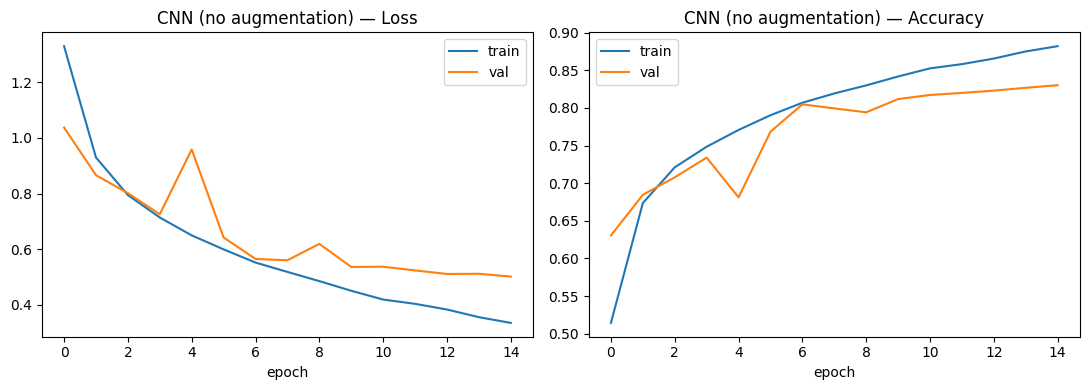

In [ ]:
cnn_plain = SimpleCNN()
cnn_plain_history = train_model(cnn_plain, train_loader_plain, val_loader, epochs=15)
plot_curves(cnn_plain_history, "CNN (no augmentation)")


## 8. Train CNN — With Data Augmentation (RandomCrop + HorizontalFlip)

Same architecture, same seed, same epoch budget — isolates the effect of augmentation.

Epoch  1/15 | train_loss 1.5172 acc 0.4391 | val_loss 1.1293 acc 0.5904
Epoch  2/15 | train_loss 1.1122 acc 0.6019 | val_loss 1.0316 acc 0.6442
Epoch  3/15 | train_loss 0.9675 acc 0.6573 | val_loss 0.9139 acc 0.6760
Epoch  4/15 | train_loss 0.8799 acc 0.6881 | val_loss 0.8064 acc 0.7162
Epoch  5/15 | train_loss 0.8211 acc 0.7110 | val_loss 0.7745 acc 0.7238
Epoch  6/15 | train_loss 0.7860 acc 0.7247 | val_loss 0.7584 acc 0.7368
Epoch  7/15 | train_loss 0.7454 acc 0.7411 | val_loss 0.6394 acc 0.7722
Epoch  8/15 | train_loss 0.7148 acc 0.7539 | val_loss 0.6210 acc 0.7860
Epoch  9/15 | train_loss 0.6835 acc 0.7635 | val_loss 0.6061 acc 0.7944
Epoch 10/15 | train_loss 0.6593 acc 0.7720 | val_loss 0.5775 acc 0.7942
Epoch 11/15 | train_loss 0.6390 acc 0.7797 | val_loss 0.5726 acc 0.7930
Epoch 12/15 | train_loss 0.6181 acc 0.7879 | val_loss 0.5623 acc 0.8066
Epoch 13/15 | train_loss 0.5980 acc 0.7929 | val_loss 0.5398 acc 0.8100
Epoch 14/15 | train_loss 0.5840 acc 0.8003 | val_loss 0.5186 acc

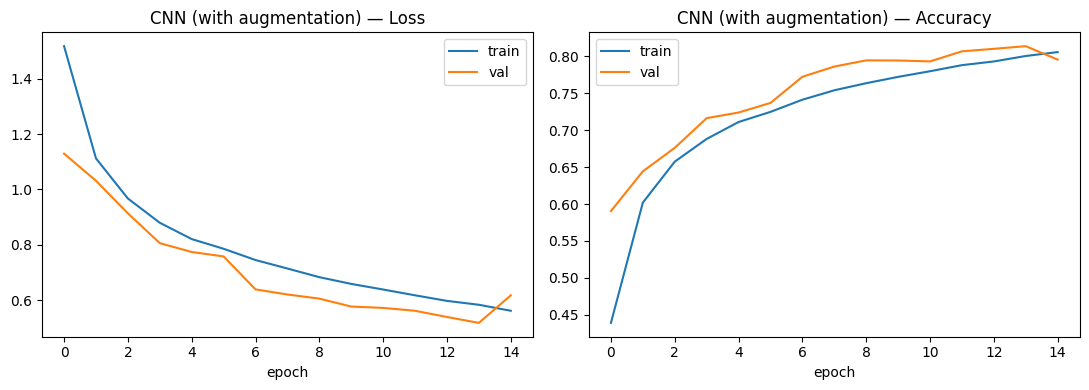

In [ ]:
train_loader_aug, _, _ = make_loaders(train_set_aug)

cnn_aug = SimpleCNN()
cnn_aug_history = train_model(cnn_aug, train_loader_aug, val_loader, epochs=15)
plot_curves(cnn_aug_history, "CNN (with augmentation)")


## 9. Measured Effect of Augmentation

The same CNN architecture was trained with and without random crop + horizontal flip augmentation. The runs used the same random seed and 15-epoch budget and were evaluated on the same validation set.

- **CNN (no augmentation):** final validation accuracy = **83.02%**; train–validation accuracy gap = **5.19 percentage points**.
- **CNN (with augmentation):** final validation accuracy = **79.54%**; train–validation accuracy gap = **1.02 percentage points**.

Augmentation therefore **reduced the train–validation gap substantially**, indicating less overfitting, but it also **reduced final validation accuracy by 3.48 percentage points** in this experiment. The result shows a clear regularization benefit, although it did not improve predictive accuracy for this particular training setup.


In [ ]:
print("Final val acc — no aug:  ", cnn_plain_history["val_acc"][-1])
print("Final val acc — with aug:", cnn_aug_history["val_acc"][-1])
print("Train-val acc gap — no aug:  ", cnn_plain_history["train_acc"][-1] - cnn_plain_history["val_acc"][-1])
print("Train-val acc gap — with aug:", cnn_aug_history["train_acc"][-1] - cnn_aug_history["val_acc"][-1])


Final val acc — no aug:   0.8302
Final val acc — with aug: 0.7954
Train-val acc gap — no aug:   0.051866666666666617
Train-val acc gap — with aug: 0.01017777777777773


## 10. Final Test-Set Evaluation & Confusion Matrix

The untouched 10,000-image test set was evaluated after training. The measured test accuracies were:

- **MLP baseline:** 52.46%
- **CNN (no augmentation): 81.78%**
- **CNN (with augmentation): 79.22%

The CNN without augmentation achieved the highest test accuracy and is therefore the strongest model by predictive performance in this experiment.


=== MLP Baseline — Test accuracy: 0.5246 ===
              precision    recall  f1-score   support

    airplane       0.58      0.60      0.59      1000
  automobile       0.65      0.61      0.63      1000
        bird       0.40      0.48      0.43      1000
         cat       0.33      0.42      0.37      1000
        deer       0.45      0.43      0.44      1000
         dog       0.48      0.35      0.41      1000
        frog       0.60      0.55      0.58      1000
       horse       0.64      0.55      0.60      1000
        ship       0.62      0.67      0.64      1000
       truck       0.58      0.57      0.58      1000

    accuracy                           0.52     10000
   macro avg       0.53      0.52      0.53     10000
weighted avg       0.53      0.52      0.53     10000



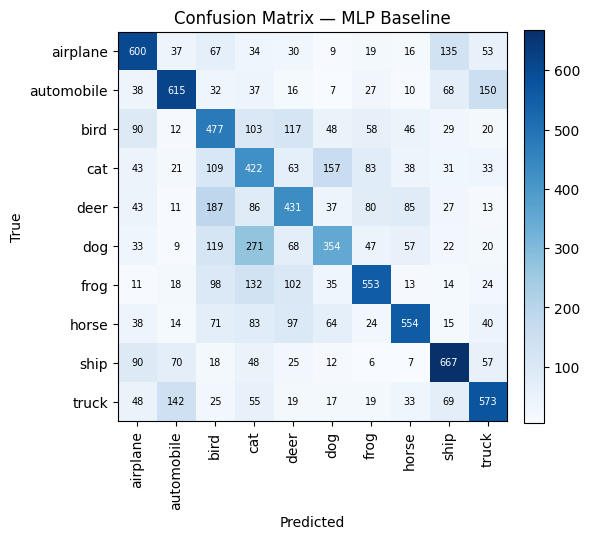

=== CNN (no aug) — Test accuracy: 0.8178 ===
              precision    recall  f1-score   support

    airplane       0.77      0.90      0.83      1000
  automobile       0.94      0.87      0.91      1000
        bird       0.88      0.58      0.70      1000
         cat       0.64      0.71      0.67      1000
        deer       0.83      0.78      0.80      1000
         dog       0.72      0.79      0.75      1000
        frog       0.87      0.87      0.87      1000
       horse       0.82      0.90      0.86      1000
        ship       0.91      0.88      0.89      1000
       truck       0.88      0.91      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



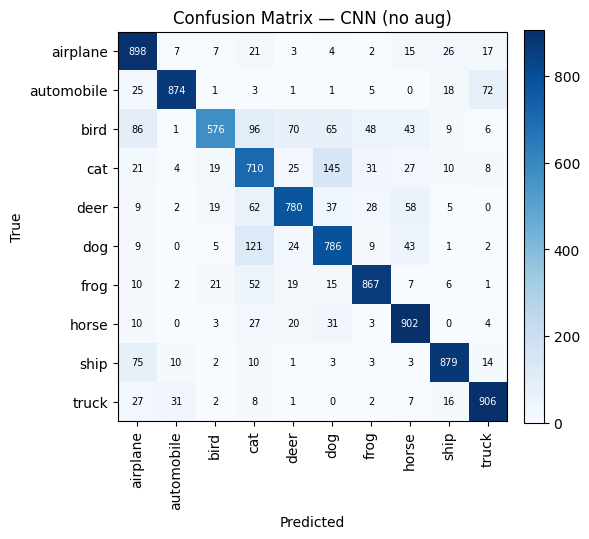

=== CNN (with aug) — FINAL MODEL — Test accuracy: 0.7922 ===
              precision    recall  f1-score   support

    airplane       0.84      0.75      0.79      1000
  automobile       0.92      0.89      0.91      1000
        bird       0.69      0.75      0.72      1000
         cat       0.80      0.52      0.63      1000
        deer       0.68      0.89      0.77      1000
         dog       0.87      0.61      0.72      1000
        frog       0.76      0.91      0.83      1000
       horse       0.89      0.77      0.83      1000
        ship       0.71      0.97      0.82      1000
       truck       0.89      0.86      0.87      1000

    accuracy                           0.79     10000
   macro avg       0.81      0.79      0.79     10000
weighted avg       0.81      0.79      0.79     10000



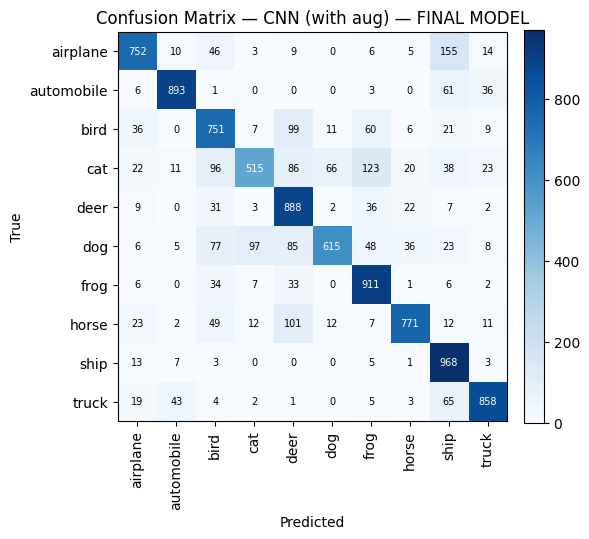

In [ ]:
def report_on_test(model, name):
    y_true, y_pred = evaluate(model, test_loader)
    acc = (y_true == y_pred).mean()
    print(f"=== {name} — Test accuracy: {acc:.4f} ===")
    print(classification_report(y_true, y_pred, target_names=classes))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(classes, rotation=90)
    ax.set_yticks(range(10)); ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"Confusion Matrix — {name}")
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i,j], ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=7)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()
    return y_true, y_pred, acc

_ = report_on_test(mlp, "MLP Baseline")
_ = report_on_test(cnn_plain, "CNN (no aug)")
y_true_best, y_pred_best, best_acc = report_on_test(cnn_aug, "CNN (with aug)")


## 11. Failure Case Analysis

The figure below shows eight misclassified test images from the CNN with data augmentation, with the true and predicted labels displayed above each image. The examples illustrate several difficult CIFAR-10 cases, including visually similar vehicle classes and ambiguous animal or object appearances.

The main systematic confusion in the test results is between **cat and dog**: the confusion matrix for the selected no-augmentation CNN contains **145 cat → dog** errors and **121 dog → cat** errors. Other notable confusions include **bird → cat (96)** and **automobile → truck (72)**. These errors are consistent with the visual similarity and low 32×32 resolution of the CIFAR-10 images.


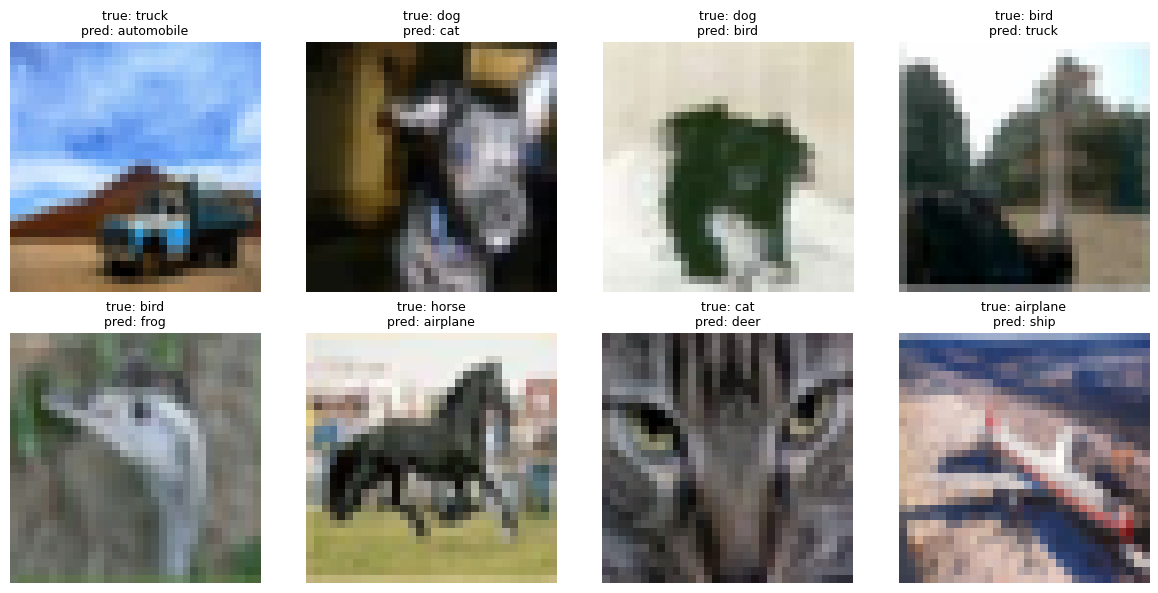

In [ ]:
mis_idx = np.where(y_true_best != y_pred_best)[0]
sample_idx = np.random.choice(mis_idx, size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.flatten(), sample_idx):
    img, label = test_set[idx]
    img = img.numpy().transpose(1,2,0)
    img = img * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)  # unnormalize
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"true: {classes[y_true_best[idx]]}\npred: {classes[y_pred_best[idx]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()


## 12. Summary Table & Final Recommendation

### Measured results

| Model | Final validation accuracy | Train–validation gap | Test accuracy |
|---|---:|---:|---:|
| MLP baseline | 52.18% | 23.19 pp | 52.46% |
| CNN (no augmentation) | **83.02%** | 5.19 pp | **81.78%** |
| CNN (with augmentation) | 79.54% | **1.02 pp** | 79.22% |

### Recommendation

**The CNN without data augmentation is recommended for deployment based on the measured results.** It achieved the highest validation accuracy (83.02%) and the highest held-out test accuracy (81.78%), substantially outperforming the MLP baseline (52.46% test accuracy). The augmented CNN produced a much smaller train–validation gap (1.02 pp versus 5.19 pp), showing stronger regularization and less overfitting, but this came with lower validation and test accuracy in the present experiment. Therefore, if predictive accuracy is the primary deployment objective, the un-augmented CNN is the better choice; augmentation remains a useful regularization option if reducing overfitting is prioritized.


In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["MLP baseline", "CNN (no aug)", "CNN (with aug)"],
    "Final Val Acc": [mlp_history["val_acc"][-1], cnn_plain_history["val_acc"][-1], cnn_aug_history["val_acc"][-1]],
    "Train-Val Gap": [
        mlp_history["train_acc"][-1] - mlp_history["val_acc"][-1],
        cnn_plain_history["train_acc"][-1] - cnn_plain_history["val_acc"][-1],
        cnn_aug_history["train_acc"][-1] - cnn_aug_history["val_acc"][-1],
    ],
    "Test Acc": [0.5246, 0.8178, 0.7922],
})

summary


,Model,Final Val Acc,Train-Val Gap
0,MLP baseline,0.5218,0.231911
1,CNN (no aug),0.8302,0.051867
2,CNN (with aug),0.7954,0.010178


### Final recommendation

**Selected model: CNN (no augmentation).** The measured held-out test accuracy is **81.78%**, compared with **79.22%** for the augmented CNN and **52.46%** for the MLP baseline. Although augmentation reduced the train–validation gap from **5.19 pp to 1.02 pp**, it did not improve validation or test accuracy in this run. The no-augmentation CNN therefore gives the best observed predictive performance for this experiment.
